# Load in MINDsmall Dataset

We begin by loading in the **MINDsmall** dataset from Kaggle. This dataset was collected from anonymized behavior logs of Microsoft News website. MINDsmall randomly sampled 1 million users who had at least 5 news clicks during a **6 day period** in November 2019. The data includes:
* `behaviors.tsv`: The click histories and impression logs of users
> * `impression_id`
> * `user_id`
> * `time`
> * `history`:
> * `impressions`: List of news displayed in this impression and user's click behaviors on them (**1 for click** and **0 for non-click**). The orders of news in a impressions have been shuffled.

* `news.tsv`: Information about the news articles involved in `behaviors.tsv`
> * `news_id`
> * `category`
> * `subcategory`
> * `title`
> * `abstract`

*Note:*
Before performing the EDA, we have conducted some initial data preprocessing (see `1_data_preprocess.ipynb` file), including:
1. **Initial Feature Engineering**: Combined news `category` and `subcategory` into a single granular `category` feature
2. **Global Indexing**: Applied global data index mapping for both `user_id` and `news_id` to ensure consistency across the dataset
3. **Behavior Parsing**: Deconstructed the raw impressions string into separate `pos_id` (clicked) and `neg_ids` (not-clicked) columns for granular interaction analysis.

EDA begins from Section 2 onwards.



In [ ]:
!pip install -q kagglehub pandas
!pip install spacy

import kagglehub
import pandas as pd
import os
import ast
import spacy

In [ ]:
#Download MINDS dataset
path = kagglehub.dataset_download("arashnic/mind-news-dataset")

#Training Folder
train_path = os.path.join(path, "MINDsmall_train")

#Load datasets
behaviors = pd.read_csv(os.path.join(train_path, "behaviors.tsv"), sep="\t", header=None)
news = pd.read_csv(os.path.join(train_path, "news.tsv"), sep="\t", header=None)

#Add in the column names
behaviors.columns = ["impression_id","user_id","time","history","impressions"]
news.columns = ["news_id","category","subcategory","title","abstract","url","title_entities","abstract_entities"]

Using Colab cache for faster access to the 'mind-news-dataset' dataset.


In [ ]:
print("Number of duplicates in behaviours.tsv:", behaviors.duplicated().sum())
behaviors.drop_duplicates(inplace=True)

print("Number of duplicates  in news.tsv:", news.duplicated().sum())
behaviors.drop_duplicates(inplace=True)

#Find total number of instances for behaviours.tsv
print("Total instances in behaviors:", len(behaviors))
# Find total number of instances for news.tsv
print("Total instances in news:", len(news))

#Find the number of users, impressions and news articles
print("Users:", behaviors["user_id"].nunique())
print("Impressions", behaviors["impression_id"].nunique())
print("Articles:", news["news_id"].nunique())


Number of duplicates in behaviours.tsv: 0
Number of duplicates  in news.tsv: 0
Total instances in behaviors: 156965
Total instances in news: 51282
Users: 50000
Impressions 156965
Articles: 51282


In [ ]:
# Find if there is any missing missing values
print(behaviors.isnull().sum())
print(news.isnull().sum())

impression_id       0
user_id             0
time                0
history          3238
impressions         0
dtype: int64
news_id                 0
category                0
subcategory             0
title                   0
abstract             2666
url                     0
title_entities          3
abstract_entities       4
dtype: int64


# 1. Data Preparation


## 1.1 Parse String Columns into List

Before further analysis, for the `behaviors.tsv` data, we first split the `impressions` string column into `pos_ids` and `neg_ids`, with the new columns representing the list of clicked and non-clicked news articles within an impression respectively.

In [ ]:
print(behaviors.sample(5))

        impression_id user_id                    time  \
131092         131093  U45308   11/12/2019 6:21:44 AM   
50106           50107   U7285   11/10/2019 1:24:32 PM   
25410           25411   U8568  11/11/2019 11:11:53 AM   
99149           99150  U16034   11/13/2019 1:45:40 PM   
132174         132175  U59330   11/11/2019 7:07:28 AM   

                                                  history  \
131092  N871 N14644 N6702 N40824 N61070 N42458 N37331 ...   
50106   N26168 N14845 N44277 N33209 N29177 N29929 N311...   
25410   N17933 N30344 N38491 N38198 N22217 N39074 N182...   
99149   N26642 N28296 N32089 N1603 N56514 N59426 N1089...   
132174  N55743 N54535 N46039 N19591 N213 N37976 N39117...   

                                              impressions  
131092  N41020-0 N32544-0 N33619-0 N7319-0 N50675-1 N1...  
50106   N61022-0 N53245-0 N61185-0 N26706-0 N44651-0 N...  
25410   N5075-0 N59981-0 N21707-0 N55689-0 N40318-0 N4...  
99149   N4510-0 N14029-0 N13907-1 N22417-0 N8509-0

In [ ]:
# Function to split impressions into clicked (pos) and non-clicked (neg)
def split_impressions(impression_str):
    if pd.isna(impression_str):
        return [], []

    # Split the string by space into individual items: ['N32544-0', 'N54125-1', ...]
    items = impression_str.split()

    pos_ids = [item.split('-')[0] for item in items if item.endswith('-1')]
    neg_ids = [item.split('-')[0] for item in items if item.endswith('-0')]

    return pos_ids, neg_ids

# Apply the function and create new columns
# Assuming your dataframe is named 'df' and the column is 'impressions'
behaviors[['pos_id', 'neg_ids']] = behaviors['impressions'].apply(
    lambda x: pd.Series(split_impressions(x))
)

behaviors.drop(columns=["impressions"], inplace=True)

In [ ]:
print(behaviors.sample(5))

        impression_id  user_id                    time  \
154359         154360    23501  11/14/2019 11:26:07 AM   
40125           40126    12610   11/13/2019 1:03:28 PM   
148441         148442    26090   11/11/2019 2:46:05 PM   
120084         120085     7109  11/14/2019 10:19:51 AM   
974               975      963  11/14/2019 12:14:56 PM   

                                                  history  \
154359  [2429, 40248, 26114, 31550, 32739, 20077, 9172...   
40125   [12649, 35908, 35908, 35908, 33635, 14656, 184...   
148441  [24979, 49759, 41662, 1083, 34255, 870, 11636,...   
120084  [4254, 46978, 33615, 12338, 48558, 43376, 4855...   
974     [43142, 19394, 36597, 16012, 10187, 39911, 358...   

                                          pos_id  \
154359                            [23776, 28249]   
40125                                    [49268]   
148441                     [31317, 32828, 12156]   
120084                                   [41587]   
974     [44612, 15532, 1

## 1.2 Global Index Mapping

We load in the previously `news.tsv` file where we combined the raw columns
`category` and `subcategory`. Next, we ensure global index mapping for `user_id` and `news_id` within both behavior and news datasets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import json

# 1. Load the global mapping files
mapping_path = '/content/drive/MyDrive/data/global_id_mappings/'

with open(f'{mapping_path}global_user_id_map.json', 'r') as f:
    user_map = json.load(f)

with open(f'{mapping_path}global_news_id_map.json', 'r') as f:
    news_map = json.load(f)

# 2. Load news.csv (already indexed) and behaviors.csv
news = pd.read_csv('/content/drive/MyDrive/data/raw datasets/news.csv')

# 3. Define a helper function for mapping lists of IDs
def map_id_list(id_list, mapping):
    # Check if id_list is actually a list (handles NaN/float cases)
    if not isinstance(id_list, list):
        return [] # or return id_list if you prefer keeping the NaN
    return [mapping.get(str(nid), nid) for nid in id_list]

# 4. Apply global indexing to behaviors_df
# Map the user_id column
behaviors['user_id'] = behaviors['user_id'].astype(str).map(user_map)

# Map the pos_id and neg_ids columns (assuming they are already list types)
behaviors['pos_id'] = behaviors['pos_id'].apply(lambda x: map_id_list(x, news_map))
behaviors['neg_ids'] = behaviors['neg_ids'].apply(lambda x: map_id_list(x, news_map))

# Split the history string into a list before applying the map_id_list function
behaviors['history'] = behaviors['history'].apply(
    lambda x: map_id_list(x.split() if isinstance(x, str) else [], news_map)
)

In [ ]:
# Verify
behaviors.sample(5)

,impression_id,user_id,time,history,pos_id,neg_ids
92525,92526,20653,11/9/2019 9:28:23 AM,"[19394, 38366, 41413, 25534, 1083, 19394, 2791...","[14458, 25357]","[48842, 40714, 31672, 33262, 9026, 33743, 7573..."
10672,10673,9185,11/11/2019 7:24:05 AM,"[9141, 9141, 27834, 43992, 38489, 17230, 4214,...","[20448, 46267, 48118, 41367, 39146, 18484, 132...","[20860, 17455, 1696, 29578, 18678, 40231, 2071..."
55599,55600,5906,11/13/2019 10:54:43 PM,"[22955, 719, 35805, 35359, 50891, 40493, 14945...",[15938],"[39464, 35647, 44612, 24154, 9162, 17986, 3410..."
6469,6470,1390,11/13/2019 1:14:26 AM,"[26296, 10639, 44143, 38058, 11175, 10900, 434...","[46796, 39708, 37936, 38768]","[22843, 30012, 5601, 47892, 3555, 30573, 16338..."
102536,102537,13824,11/13/2019 4:23:32 PM,"[45033, 107, 41908, 23959, 48105, 22147, 43756...","[15532, 10307]","[32922, 6050, 41397, 12101, 39507, 35088, 4444..."


Load in the train, validation and test sets for analysis.

In [ ]:
import pandas as pd

splitsets_path = '/content/drive/MyDrive/data/'

train_df = pd.read_csv(splitsets_path + "train.csv")
val_df   = pd.read_csv(splitsets_path + "val.csv")
test_df  = pd.read_csv(splitsets_path + "test.csv")

## 1.3 Number of Impression Rows
Each row is defined as an **impression**, an instance where a user is reccomended a list of Microsoft news articles to read. The **temporal split** to generate the train, val, test set is done such that first 4 days are reserved for train, the 5th day is reserved for validation, and the 6th day is reserved for testing. This respects the temporal sequence of the data to prevent data leakage. Therefore, the split ratio is not exactly 80:10:10.

In [ ]:
print("Number of Impression Rows")
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Number of Impression Rows
Train: 141558, Val: 31624, Test: 30270


In [ ]:
train_n = len(train_df)
val_n   = len(val_df)
test_n  = len(test_df)

total = train_n + val_n + test_n

train_ratio = train_n / total
val_ratio   = val_n / total
test_ratio  = test_n / total

print("--- Temporal Split ---")
print(f"Train: {train_ratio:.2%}")
print(f"Val:   {val_ratio:.2%}")
print(f"Test:  {test_ratio:.2%}")

--- Temporal Split ---
Train: 69.58%
Val:   15.54%
Test:  14.88%


## 1.4 Number of Users Across Dataset
We analyse the number of users we have across the test, val and test sets. We see that almost **30%** of users from the val and test set do not appear in the train set.

In [ ]:
print("Train unique users:", train_df['user_id'].nunique())
print("Val unique users:  ", val_df['user_id'].nunique())
print("Test unique users: ", test_df['user_id'].nunique())

Train unique users: 40148
Val unique users:   20884
Test unique users:  20179


In [ ]:
all_users = pd.concat([
    train_df['user_id'],
    val_df['user_id'],
    test_df['user_id']
])

print("Total unique users (all splits):", all_users.nunique())

Total unique users (all splits): 50000


In [ ]:
val_users   = set(val_df['user_id'])
test_users  = set(test_df['user_id'])
train_users = set(train_df['user_id'])

# Seen before (overlap with train)
val_seen_in_train  = val_users & train_users
test_seen_in_train = test_users & train_users

In [ ]:
val_pct  = 100 - (len(val_seen_in_train) / len(val_users) * 100)
test_pct = 100 - (len(test_seen_in_train) / len(test_users) * 100)

print(f"Percentage of users in Validation NOT set seen in Train: {val_pct:.2f}%")
print(f"Percentage of users in Test NOT set seen in Train: {test_pct:.2f}%")

Percentage of users in Validation NOT set seen in Train: 28.08%
Percentage of users in Test NOT set seen in Train: 29.08%


#2. User Engagement

##2.1 Impressions per User
We analyse the number of impressions each user engages in within the dataset timeframe. We are particularly interested whether most users can be represented by repeated engagement within the dataset.

From the results below, we can conclude the following:
* **Sparsity**: The median is **2 impressions**, meaning half of the users logged 2 or fewer interactions over the 6-day period. Specifically, ~32% of users appear only **once**. This confirms that the majority of the audience has very limited activity within the current timeframe of data collection.

* **Modeling Implications**: This distribution creates a sparse-data challenge. For the vast majority of users, the model lacks repeated session data to identify current trends or user preferences. Consequently, the recommendation engine must rely heavily on the `history` feature (past long-term interests) rather than immediate session behaviors to provide accurate content for the bulk of the user base.

Average Impressions per User:
3.1393
Median Impressions per User:
2.0
Users with 1 impression: 32.77%

Detailed Distribution (Top 10):
session_count
1     16383
2     11867
3      7490
4      4535
5      2808
6      1987
7      1305
8       897
9       666
10      500
Name: count, dtype: int64


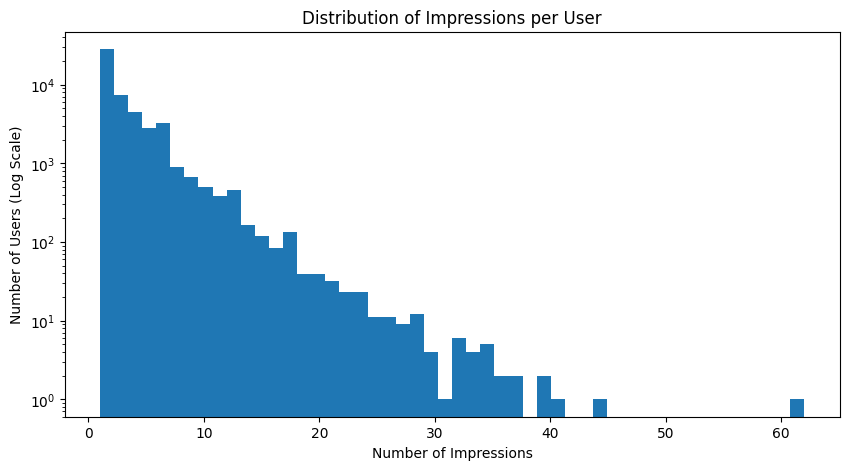

In [ ]:
import matplotlib.pyplot as plt

# Group by user_id to get the count of sessions per user
user_session_counts = behaviors.groupby('user_id').size().reset_index(name='session_count')

# 1. Calculate the total number of unique users
total_users = len(user_session_counts)

# 2. Create a distribution dataframe with counts and percentages
distribution = user_session_counts['session_count'].value_counts().sort_index().to_frame(name='user_count')
distribution['percentage'] = (distribution['user_count'] / total_users) * 100

one_imp_pct = distribution.loc[1, 'percentage'] if 1 in distribution.index else 0

# Show the overall distribution (e.g., how many users have 1 session, 2 sessions, etc.)
distribution = user_session_counts['session_count'].value_counts().sort_index()
print("Average Impressions per User:")
print(user_session_counts['session_count'].mean())
print("Median Impressions per User:")
print(user_session_counts['session_count'].median())
print(f"Users with 1 impression: {one_imp_pct:.2f}%")
print("\nDetailed Distribution (Top 10):")
print(distribution.head(10))

# Plot the distribution
plt.figure(figsize=(10, 5))
plt.hist(user_session_counts['session_count'], bins=50, log=True)
plt.title('Distribution of Impressions per User')
plt.xlabel('Number of Impressions')
plt.ylabel('Number of Users (Log Scale)')
plt.show()

## 2.2 Positive and Negative Clicks

###2.2.1 Overall Click to Not-clicked Ratio
We find that the dataset is dominated by negative interactions. A negative-to-positive ratio of 24:1 means that for every single article a user clicks, they are ignoring approximately 24 others. A global CTR of 4.04% indicates that users are **highly selective**.

* **Model Implications**: We must perform **negative sampling**. Training on all 24 negatives per positive would introduce too much noise and slow down convergence.

In [ ]:
# Calculate counts for each impression
behaviors['pos_count'] = behaviors['pos_id'].apply(len)
behaviors['neg_count'] = behaviors['neg_ids'].apply(len)
behaviors['total_shown'] = behaviors['pos_count'] + behaviors['neg_count']

# Calculate Click-Through Rate (CTR) per impression
behaviors['impression_ctr'] = behaviors['pos_count'] / behaviors['total_shown']

In [ ]:
total_pos = behaviors['pos_count'].sum()
total_neg = behaviors['neg_count'].sum()

print(f"Total Positive Clicks: {total_pos}")
print(f"Total Negative Impressions: {total_neg}")
print(f"Global Negative-to-Positive Ratio: {total_neg / total_pos:.0f} : 1")
print(f"Global CTR: {(total_pos / (total_pos + total_neg)) * 100:.2f}%")

Total Positive Clicks: 236344
Total Negative Impressions: 5607100
Global Negative-to-Positive Ratio: 24 : 1
Global CTR: 4.04%


###2.2.2 User-level Click-through Rate
We confirm that the majority of users in the dataset are very selective, with 75% of users clicking on only approximately **9%** of the articles they are presented with.

User CTR Statistics:
count    50000.000000
mean         0.085461
std          0.104511
min          0.003448
25%          0.028986
50%          0.048544
75%          0.090909
max          0.666667
Name: user_ctr, dtype: float64


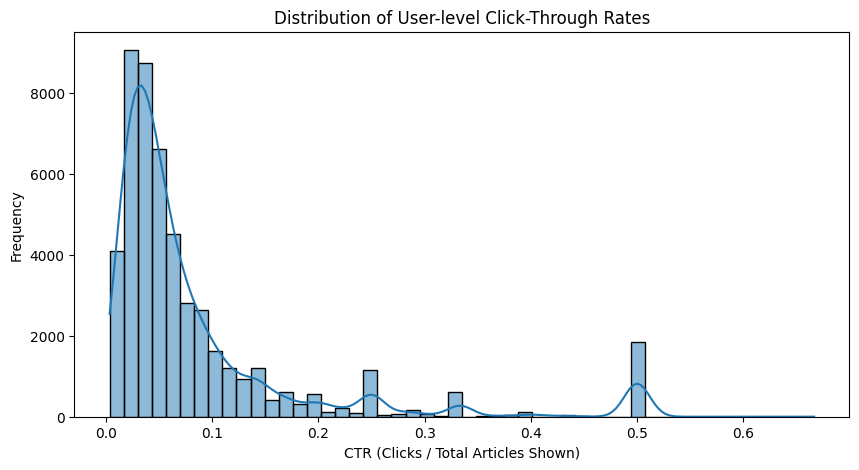

In [ ]:
user_click_stats = behaviors.groupby('user_id').agg({
    'pos_count': 'sum',
    'neg_count': 'sum'
}).reset_index()

user_click_stats['user_ctr'] = user_click_stats['pos_count'] / (user_click_stats['pos_count'] + user_click_stats['neg_count'])

print("User CTR Statistics:")
print(user_click_stats['user_ctr'].describe())

# Visualize User CTR Distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(user_click_stats['user_ctr'], bins=50, kde=True)
plt.title('Distribution of User-level Click-Through Rates')
plt.xlabel('CTR (Clicks / Total Articles Shown)')
plt.ylabel('Frequency')
plt.show()

###2.2.3 Number of Positive Clicks within an Impression
We find that over **72.5%** of impression sessions result in exactly **one click** only. It is extremely rare for a user to click more than three articles in a single viewing session (less than 12% of the time).

* **Model Implications**: We may not need complex listwise ranking models that look at the relationship between multiple clicked items in a single session, because those sessions are rare.

In [ ]:
pos_dist = behaviors['pos_count'].value_counts(normalize=True).sort_index() * 100
print("Percentage of Impressions by Number of Clicks:")
print(pos_dist.head(10))

Percentage of Impressions by Number of Clicks:
pos_count
1     72.556302
2     16.290893
3      5.901316
4      2.532412
5      1.246775
6      0.600134
7      0.328099
8      0.188577
9      0.126143
10     0.074539
Name: proportion, dtype: float64


##2.3 User History


The codes below aim to understand `history` in the behaviours dataset.

###2.3.1 Static User History
With the check below, we verify that in the MINDs dataset, the `history` is a **static** snapshot of the user's behavior prior to the 6-day logging period. It **does not update** in real-time as the user clicks new artciles in the behaviors file.

In [ ]:
# Convert list to tuple to make it hashable for unique counting
behaviors['history_tuple'] = behaviors['history'].apply(tuple)

# Group by user and count unique history versions
history_consistency = behaviors.groupby('user_id')['history_tuple'].nunique()

# Check if any user has more than 1 unique history
non_static_users = (history_consistency > 1).sum()

if non_static_users == 0:
    print("Verification Successful: All users have a static history across all sessions.")
else:
    print(f"Alert: Found {non_static_users} users with changing history.")

# Clean up the temporary column
behaviors.drop(columns=['history_tuple'], inplace=True)

Verification Successful: All users have a static history across all sessions.


###2.3.2 User History Distribution
Ou findings can be summarised as follows:

* **1.78%** of **users** in the dataset have no prior history. For these users, the model must rely on the global popularity (CTR) of articles rather than personalised user interests.
* These users appear in approximately **2.06%** of **rows** across the entire impressions dataset
* 50% of users have at least 11 news articles in their history.
* We have extreme outliers, which some users having over 500 news articles in their history

**Model Implications**
* Our model will be able to build a relatively strong user interest profile as 50% of users have at least 11 news articles in their history. We do **not** need to rely heavily on global features such as news CTR (popularity).


In [ ]:
no_history = behaviors['history'].isna() | (behaviors['history'].str.strip() == "")

print("Rows with no history:", no_history.sum())
print(f"Percentage of rows with no history: {no_history.sum() / len(behaviors) * 100:.2f}%")

Rows with no history: 3238
Percentage of rows with no history: 2.06%


In [ ]:
import seaborn as sns

# We find the lenggth of each user history
behaviors['history_length'] = behaviors['history'].apply(
    lambda x: len(x) if x else 0
)

# We retrieve the most relevant the user history, using the maximum history length
user_history = behaviors.groupby('user_id')['history_length'].max().reset_index()

# Get a summary of user history lengths
print("User History Length Statistics:")
print(user_history['history_length'].describe())

# Step 4: Count users with zero history
zero_history_count = (user_history['history_length'] == 0).sum()
total_users = len(user_history)

zero_history_pct = (zero_history_count / total_users) * 100

print(f"\nUsers with 0 history: {zero_history_count} ({zero_history_pct:.2f}%)")

User History Length Statistics:
count    50000.000000
mean        18.521160
std         23.900679
min          0.000000
25%          5.000000
50%         11.000000
75%         22.000000
max        558.000000
Name: history_length, dtype: float64

Users with 0 history: 892 (1.78%)


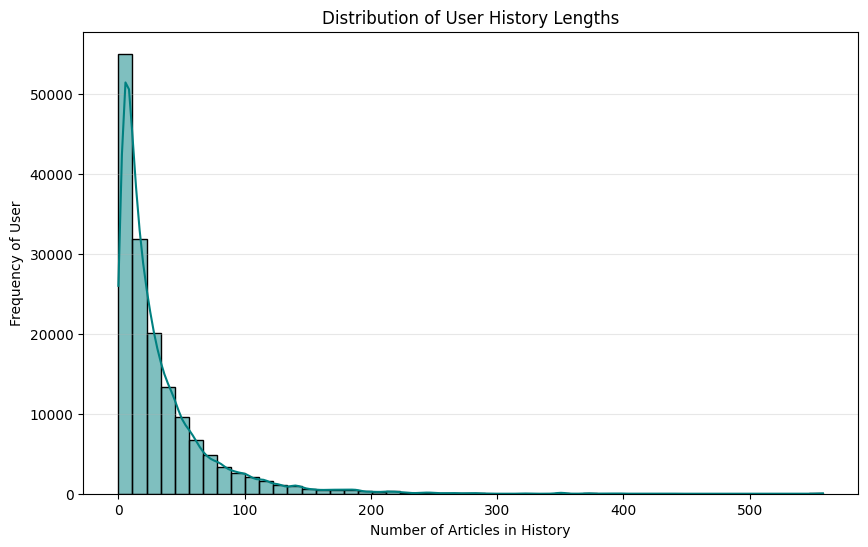

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(behaviors['history_length'], bins=50, kde=True, color='teal')
plt.title('Distribution of User History Lengths')
plt.xlabel('Number of Articles in History')
plt.ylabel('Frequency of User')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. User and News Interaction Analysis

## 3.1 Verify Referential Integrity
We verify 100% referential integrity between news metadata and behaviors logs. All 51,282 unique articles have both descriptive features and recorded interactions.

* **Model Implication**: Since every article appears in the behaviors, our model can consistently perform Content-Based Filtering and feature lookups (such as category or title embeddings) for every news article it encounters. This eliminates the need for "Unknown" or "Missing" token handling, ensuring that the signal from the user's long-term history is never diluted by missing news data.

In [ ]:
# 1. Get the set of all news IDs in your metadata
news_ids_in_metadata = set(news['news_id'])

# 2. Extract all unique IDs from the behaviors dataframe
# We flatten the lists in 'history', 'pos_id', and 'neg_ids'
history_ids = set([item for sublist in behaviors['history'] for item in sublist])
pos_ids = set([item for sublist in behaviors['pos_id'] for item in sublist])
neg_ids = set([item for sublist in behaviors['neg_ids'] for item in sublist])

# 3. Combine all IDs seen in behaviors
behavior_ids_all = history_ids.union(pos_ids).union(neg_ids)

# 4. Find the "Ghost" articles (In news metadata but never appeared in behaviors)
ghost_articles = news_ids_in_metadata - behavior_ids_all

# 5. Find "Missing" metadata (In behaviors but not in news metadata)
missing_metadata = behavior_ids_all - news_ids_in_metadata

#6. Verfiy referential integrity
is_consistent = len(ghost_articles) == 0 and len(missing_metadata) == 0

print(f"Referential Integrity: {'✅' if is_consistent else '❌'}")
print(f"Total unique news articles in metadata: {len(news_ids_in_metadata)}")
print(f"Total unique news articles found in behaviors: {len(behavior_ids_all)}")
print(f"---")
print(f"Articles with NO behavior records: {len(ghost_articles)}")
print(f"Behavioral IDs with NO metadata: {len(missing_metadata)}")

Referential Integrity: ✅
Total unique news articles in metadata: 51282
Total unique news articles found in behaviors: 51282
---
Articles with NO behavior records: 0
Behavioral IDs with NO metadata: 0


##3.2 Diversity of User Interests
We initially find that users interact with multiple unique categories, with a user having an average of interacting with 13.64 different categories (out of 80). Shannon Entropy analysis reveals that many users have highly concentrated interests rather than a balanced distribution.
* **Model Implication**: We can perform unsupervised clustering to segment users based on the relationship between their category volume (Unique Count) and interest concentration (Shannon Entropy). This will potentially be a engineered feature for users, called `diversity_score`.


In [ ]:
# Map news IDs in history to their categories to see how many unique categories users read
news_cat_map = news.set_index('news_id')['category'].to_dict()

def count_unique_cats(hist):
    return len(set([news_cat_map.get(nid) for nid in hist if nid in news_cat_map]))

behaviors['unique_categories'] = behaviors['history'].apply(count_unique_cats)
print(f"Average unique categories per user history: {behaviors['unique_categories'].mean():.2f}")

Average unique categories per user history: 13.64


In [ ]:
from collections import Counter
import math

# 1. Pre-calculate the mapping for speed
news_cat_map = news.set_index('news_id')['category'].to_dict()

def calculate_fast_metrics(history):
    # Handle empty or null history
    if not history or not isinstance(history, list):
        return 0, 0.0

    # Map IDs to Categories (List comprehension is faster than .apply)
    cats = [news_cat_map[nid] for nid in history if nid in news_cat_map]
    if not cats:
        return 0, 0.0

    n = len(cats)
    # Unique Count
    unique_count = len(set(cats))

    # Fast Entropy Calculation (Pure Python/Math)
    counts = Counter(cats).values()
    entropy = 0.0
    for c in counts:
        p = c / n
        entropy -= p * math.log2(p)

    return unique_count, entropy

# 2. Use a list comprehension to build the data (much faster than .apply)
# This processes the entire column in one go
results = [calculate_fast_metrics(h) for h in behaviors['history']]

# 3. Assign back to DataFrame
behaviors['unique_cat_count'], behaviors['history_entropy'] = zip(*results)

print("Calculation complete.")

Calculation complete.


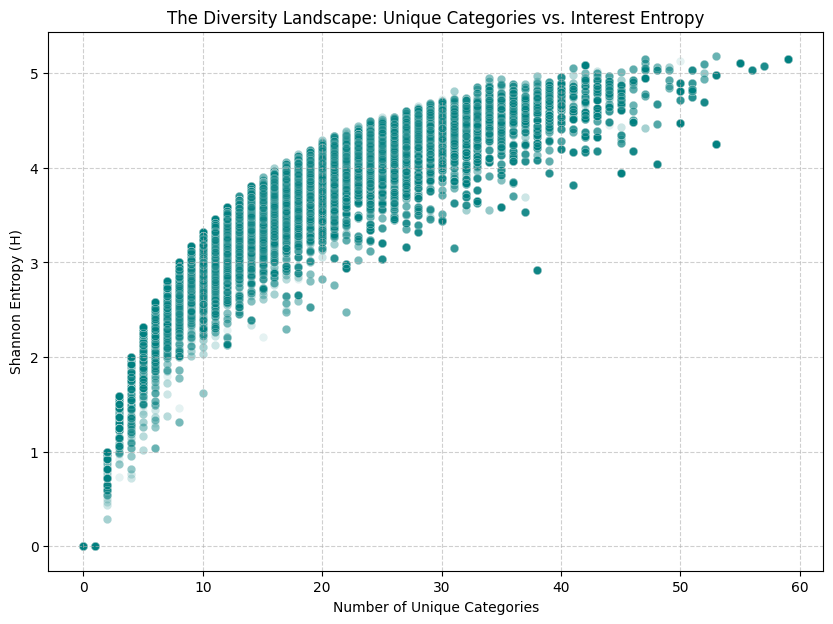

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

# We use alpha=0.1 because there are 150k points; this reveals the density "heat"
sns.scatterplot(data=behaviors, x='unique_cat_count', y='history_entropy',
                alpha=0.1, color='teal')

plt.title("The Diversity Landscape: Unique Categories vs. Interest Entropy")
plt.xlabel("Number of Unique Categories")
plt.ylabel("Shannon Entropy (H)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 4. Temporal Analysis

We are working with MINDsmall which spans **6 days**, from **9 November 2019** (Saturday) to **14 November 2019** (Thursday). Because of this short window, we will analyse the impression volume by hour, instead of by day of the week. We will focus on the time of day (hourly analysis) to explore how users consume news throughout the day (for e.g. during commutes, lunch breaks, and before bed etc.)

## 4.1 Analysis of 6-day Window
We see that the daily impression volume spikes on Monday, 11 November, and the daily impression volume is significantly higher on weekdays compared to the weekends. Although our models ultimately remain agnostic to the day of the week, this distrbribution provides context for our 4:1:1 temporal split (4 days training, 1 day validation, 1 day testing).

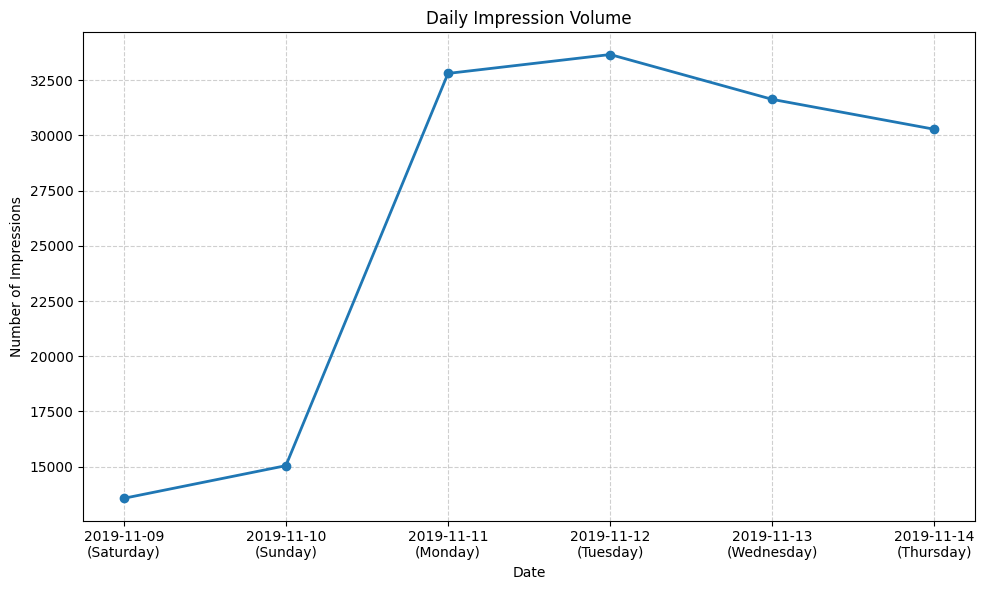

In [ ]:
# 1. Convert to datetime (robust parsing)
behaviors['time'] = pd.to_datetime(behaviors['time'], errors='coerce')

# 2. Extract pure date (better for grouping)
behaviors['date'] = behaviors['time'].dt.date

# 3. Aggregate: impressions per day
daily_trend = (
    behaviors
    .groupby('date')
    .size()
    .sort_index()
)

# 4. Create readable labels (only for plotting)
date_labels = pd.to_datetime(daily_trend.index).strftime('%Y-%m-%d\n(%A)')

# 5. Plot
plt.figure(figsize=(10, 6))

plt.plot(daily_trend.index, daily_trend.values, marker='o', linewidth=2)

# 6. Improve readability
plt.title('Daily Impression Volume')
plt.ylabel('Number of Impressions')
plt.xlabel('Date')

plt.xticks(daily_trend.index, date_labels, rotation=0)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

# 7. Save + show
plt.savefig('daily_impressions_trend.png', dpi=300)
plt.show()

## 4.2 Hourly Analysis
###4.2.1 Hourly Impression Volume
We see that the traffic volume of impressions remain generally high during the day, peaking during the morning from 08:00 to 11:00.

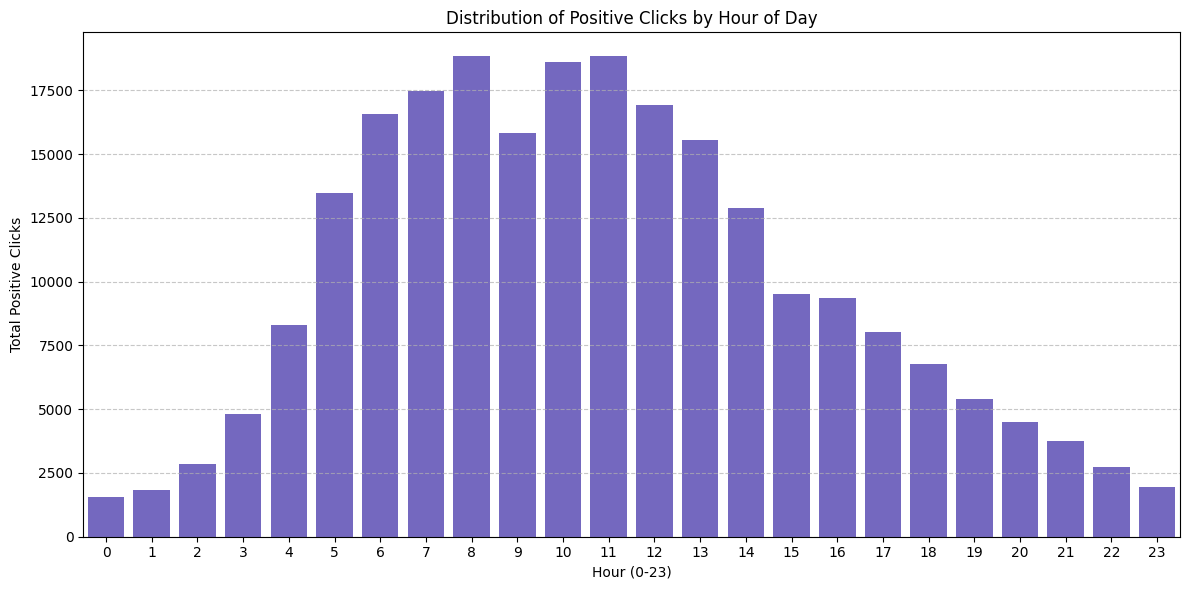

In [ ]:
# 1. Ensure 'time' is in datetime format and extract the hour
behaviors['time'] = pd.to_datetime(behaviors['time'])
behaviors['hour'] = behaviors['time'].dt.hour

# 2. Calculate positive clicks from the pre-extracted 'pos_ids' column
behaviors['click_count'] = behaviors['pos_id'].apply(len)

# 3. Group by hour and sum the positive clicks
hourly_clicks = behaviors.groupby('hour')['click_count'].sum().reset_index()

# 4. Visualization
plt.figure(figsize=(12, 6))
sns.barplot(data=hourly_clicks, x='hour', y='click_count', color='slateblue')

plt.title('Distribution of Positive Clicks by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Total Positive Clicks')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('hourly_positive_clicks.png')

###4.2.2 Hourly Changes in User CTR
From the line graph, we see how the probability of an article click changes drastically throughout the day.
* **Morning:** The **highest** CTR window in the entire 24-hour cycle is from **07:00-09:00**. This can suggest users are waking up or commuting, and their interaction with news is highly intentional.
* **Mid-day**: Clicks per impression reach their lowest point between 11:00 and 16:00, suggesting that even if traffic is high during work hours, the willingness to click is significantly lower.
* **Evening**: The second major peak is from **20:00-22:00**. This can represent leisure browsing. Users may be more likely to click on longer articles, features, or entertainment news that they did not have time for during the day.

**Model Implications:**
* The effect of hour of news consumption on the probability of a user click is not linear.
* We can consider **cyclic encoding** of the time variable. This ensures that our model understands the 23rd hour (11pm) is near the 0 hour (midnight).









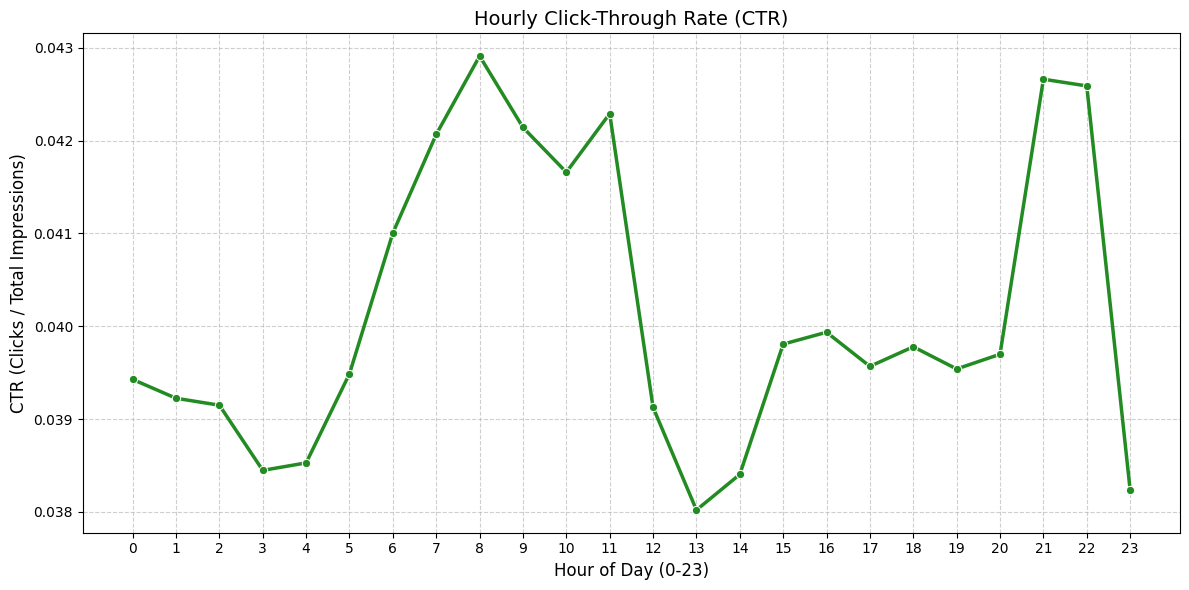

In [ ]:
# 1. Calculate counts per row
# Using pre-extracted pos_ids and neg_ids lists
behaviors['num_pos'] = behaviors['pos_id'].apply(len)
behaviors['num_neg'] = behaviors['neg_ids'].apply(len)
behaviors['total_impressions'] = behaviors['num_pos'] + behaviors['num_neg']

# 2. Group by hour and calculate aggregate CTR
hourly_stats = behaviors.groupby('hour').agg({
    'num_pos': 'sum',
    'total_impressions': 'sum'
})
hourly_stats['ctr'] = hourly_stats['num_pos'] / hourly_stats['total_impressions']

# 3. Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_stats, x='hour', y='ctr', marker='o', color='forestgreen', linewidth=2.5)

plt.title('Hourly Click-Through Rate (CTR)', fontsize=14)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('CTR (Clicks / Total Impressions)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('hourly_ctr_proportion.png')

###4.2.3 Hourly Category Shift
We analyse whether certain categories are more popular during certain time of the day. From the heatmap, we do see that certain news categories show subtle shifts in popularity depending on the time of day. Examples include:

* "news-world" news peak from 08:00 to 12:00
*  "music-celebrity" news peak from 20:00 to 23:00

This tells us that the relevance of news articles do not just depend on the user and news content, but also **when** the user is browsing.

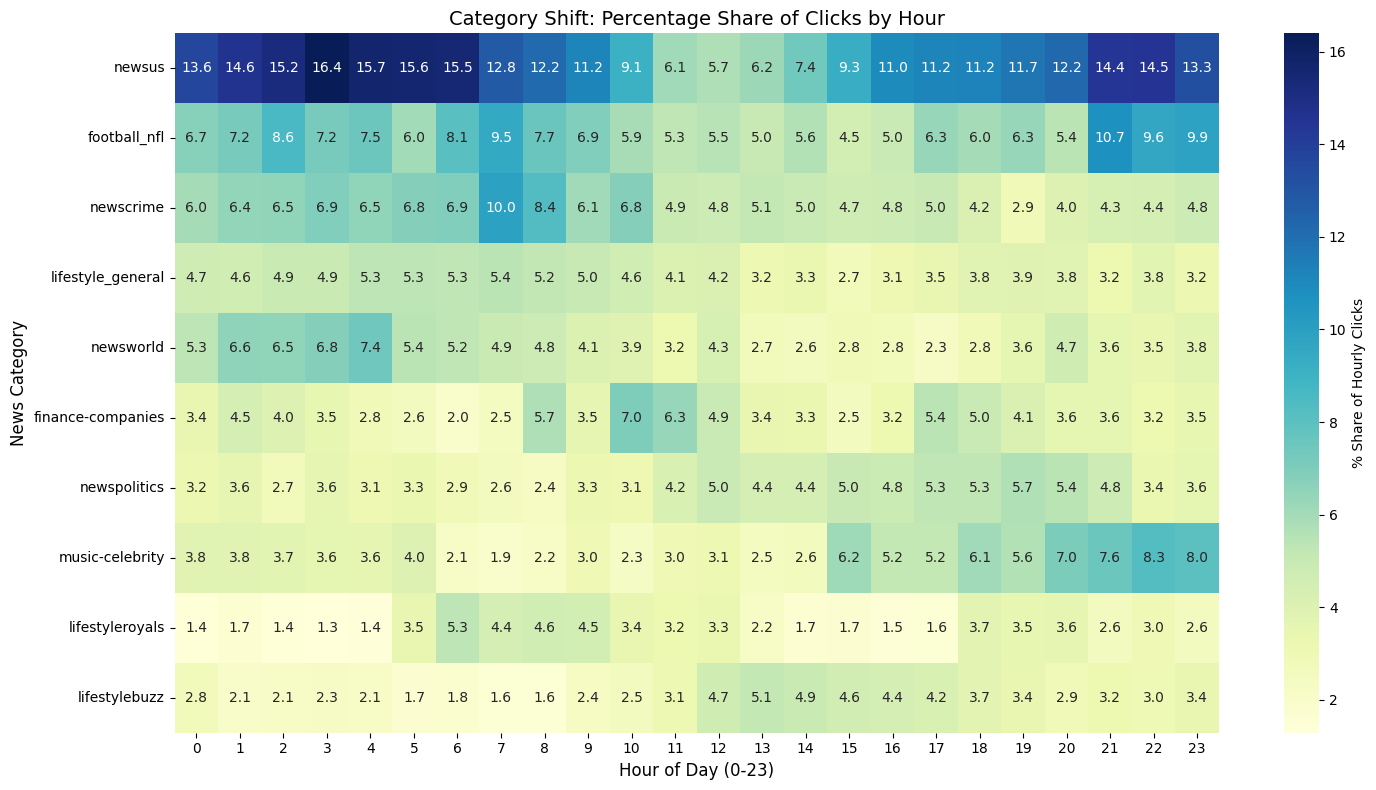

In [ ]:
# 1. Prepare the Click-Level Data
# Explode pos_ids so each click has its own row with the associated hour
clicks_df = behaviors.explode('pos_id')[['hour', 'pos_id']]
clicks_df['category'] = clicks_df['pos_id'].map(news_cat_map)

# 2. Calculate Hourly Proportions
# Create a cross-tabulation of Hour vs Category
hourly_cat_counts = pd.crosstab(clicks_df['hour'], clicks_df['category'])

# Convert counts to percentages per hour (each row sums to 100%)
hourly_cat_pct = hourly_cat_counts.div(hourly_cat_counts.sum(axis=1), axis=0) * 100

# 3. Filter for Top 10 Categories
# 80 categories are too many for one graph; we focus on the most impactful ones
top_10_cats = clicks_df['category'].value_counts().nlargest(10).index
hourly_cat_filtered = hourly_cat_pct[top_10_cats].T # Transpose for the heatmap

# 4. Visualization: Hourly Category Heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(hourly_cat_filtered, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': '% Share of Hourly Clicks'})

plt.title('Category Shift: Percentage Share of Clicks by Hour', fontsize=14)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('News Category', fontsize=12)
plt.tight_layout()
plt.savefig('category_shift_heatmap.png')
plt.show()

###4.3 News Content Recency
As the exact publication date of each article is not known, we use a "First-Seen" proxy to estimate the age of each news article. This is calculated as the duration between an article's initial appearance in the dataset and the specific time of a user's interaction.

Our analysis reveals an exponential decay in engagement: the frequency of positive clicks drops sharply as the time since first appearance increases. This suggests that:

* **Engagement is Time-Sensitive:** Most interactions occur within the first 12–24 hours, after which the probability of a click diminishes rapidly.

**Model Implications**
* The model must prioritise content freshness as a primary ranking signal because news relevance expires quickly, often within 24 to 48 hours.

Text(0, 0.5, 'Frequency of Positive Clicks')

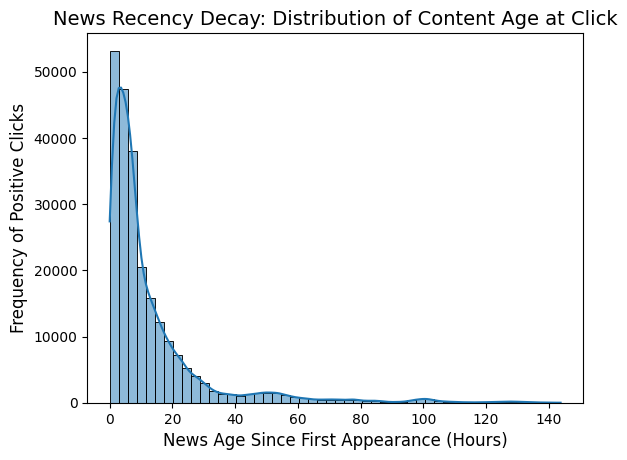

In [ ]:
# 1. Map each News ID to its first appearance in the dataset
first_seen = behaviors.explode('pos_id').groupby('pos_id')['time'].min().to_dict()

# 2. Calculate the age (in hours) of each clicked article
def get_click_ages(row):
    return [(row['time'] - first_seen[nid]).total_seconds() / 3600
            for nid in row['pos_id'] if nid in first_seen]

click_ages = behaviors.apply(get_click_ages, axis=1).explode()

# 3. Plot the distribution
import seaborn as sns
sns.histplot(click_ages, bins=50, kde=True)
plt.title('News Recency Decay: Distribution of Content Age at Click', fontsize=14)
plt.xlabel('News Age Since First Appearance (Hours)', fontsize=12)
plt.ylabel('Frequency of Positive Clicks', fontsize=12)

###4.4 User Impression Time Interval
* **Habitual News Consumption:** The most prominent finding from the graph below is the 24-hour periodicity. There are sharp spikes at 24-hour intervals (24, 48, 72 etc.). This tells us that many users check the news at the same exact time every day.

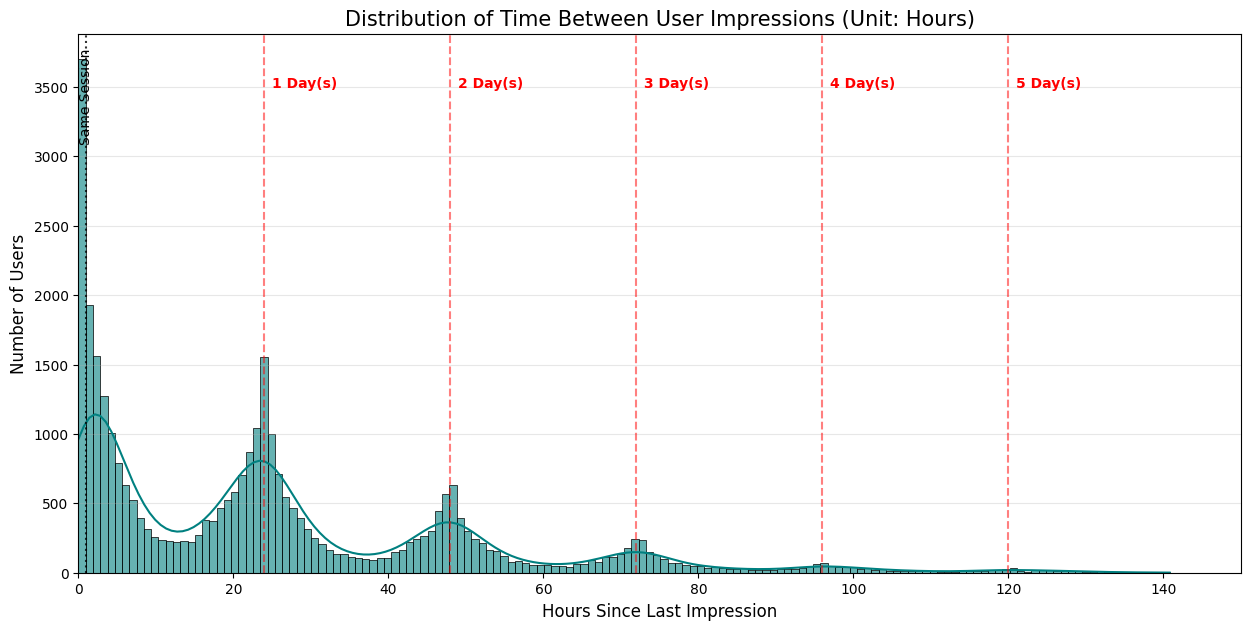

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculation (assuming 'behaviors' is sorted by user and time)
behaviors['interval_hours'] = (
    behaviors.groupby('user_id')['time'].diff().dt.total_seconds() / 3600
)

# Get the most recent interval for users with >= 2 impressions
recent_intervals = behaviors.groupby('user_id')['interval_hours'].last().dropna()

# 2. Plotting for Maximum Clarity
plt.figure(figsize=(15, 7))

# We use a log scale on the X-axis because the difference between
# 1 minute (0.01h) and 1 day (24h) is huge.
sns.histplot(recent_intervals, bins=150, kde=True, color='teal', alpha=0.6)

# --- The "Clarity" Additions ---

# Add vertical lines at 24-hour intervals (Daily Cycles)
for day in [24, 48, 72, 96, 120]:
    plt.axvline(day, color='red', linestyle='--', alpha=0.5, label=f'{day}h Mark' if day==24 else "")
    plt.text(day+1, plt.ylim()[1]*0.9, f'{day//24} Day(s)', color='red', fontweight='bold')

# Add a vertical line at 1 hour (Session Boundary)
plt.axvline(1, color='black', linestyle=':', alpha=0.8)
plt.text(0.1, plt.ylim()[1]*0.8, 'Same Session', rotation=90, color='black')

# Formatting
plt.title('Distribution of Time Between User Impressions (Unit: Hours)', fontsize=15)
plt.xlabel('Hours Since Last Impression', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.xlim(0, 150) # Focus on the first week
plt.grid(axis='y', alpha=0.3)

plt.show()

##5. User Histories in Training, Validation and Test Dataset Analysis


In [ ]:
train_users = set(train_df['user_id'])
val_users = set(val_df['user_id'])
test_users = set(test_df['user_id'])

new_users_in_val = val_users - train_users
new_users_in_test = test_users - train_users

print("Number of new users in validation:", len(new_users_in_val))
print("Percentage of new users in validation:", (len(new_users_in_val) / len(val_users)) * 100 )
print("Number of new users in test:", len(new_users_in_test))
print("Percentage of new users in test:", (len(new_users_in_test) / len(test_users)) * 100)

Number of new users in validation: 5864
Percentage of new users in validation: 28.078912085807318
Number of new users in test: 5869
Percentage of new users in test: 29.084692006541452


With ~28% of new users in validation and ~29% of new users in test set, this can give rise to strong cold-start problem (users) as almost 1 in 3 users are not seen in training.

*   **Model Implication**: User-based CF will fail badly as it requires user similarity. However, new users in test/validation set will have no similar users we can find because we have no data about this user.
* We cannot only rely on trainable user embeddings.




In [ ]:
# Count rows where the list of positive IDs is empty
zero_pos_count = (behaviors['pos_id'].apply(len) == 0).sum()
print(f"Number of impressions with 0 positive clicks: {zero_pos_count}")

Number of impressions with 0 positive clicks: 0
